# SSD 配對交易系統：各階段運作邏輯解析

本系統採用滾動回測架構，將配對交易的完整流程劃分為三個主要階段：
**形成期 (Formation)**、**交易期 (Trading)** 與 **績效評估 (Performance)**。以下為各階段的詳細運作邏輯與核心數學公式。

In [22]:
"""
SSD 配對交易滾動回測系統
架構：Formation (選對) → Trading (交易) → Performance (績效評估)
"""

import sqlite3
import warnings
import itertools
import os
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

warnings.filterwarnings("ignore")

## 1. 形成期 (Formation)：挑選最佳配對

**主要目標：** 在歷史資料中尋找走勢最相近、具有高度「共整合 (Cointegration) 潛力」的股票組合。

**運作邏輯與核心公式：**

* **價格標準化 (Normalization)**
  由於不同股票的絕對價格差異極大，直接比較價格差距沒有意義。系統會將每檔股票在形成期第一天的價格設為基準 1，將所有標的對齊在同一起跑線。
  

  $$
  P_{norm}(t) = \frac{P(t)}{P(0)}
  $$

* **計算最小平方距離 (SSD, Sum of Squared Differences)**
  針對所有標的進行兩兩配對，計算它們在形成期內「標準化價格差值」的平方和。SSD 數值越小，代表這兩檔股票在過去一段時間的走勢越緊密。
  

  $$
  SSD = \sum \left( P_{norm, A}(t) - P_{norm, B}(t) \right)^2
  $$

* **篩選與輸出**
  系統會根據 SSD 數值由小到大排序，選出最小的前 $N$ 對股票（預設 `top_n = 20`），作為接下來交易期的觀察與操作標的。

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# Class 1：Formation（形成期）
# 功能：計算標的兩兩之間的 SSD 值，選出最佳配對
# ══════════════════════════════════════════════════════════════════════════════
class Formation:
    def __init__(self, price_df: pd.DataFrame, top_n: int = 5, output_dir: str = "."):
        self.price_df = price_df.copy()
        self.top_n = top_n
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)

        self.normalized_df: pd.DataFrame = pd.DataFrame()
        self.ssd_records: list = []
        self.selected_pairs: pd.DataFrame = pd.DataFrame()

    def normalize_prices(self) -> pd.DataFrame:
        """標準化價格：P_norm(t) = P(t) / P(0)"""
        first_prices = self.price_df.iloc[0]
        self.normalized_df = self.price_df.div(first_prices, axis=1)
        return self.normalized_df

    def compute_ssd(self) -> pd.DataFrame:
        """計算所有兩兩組合的 SSD (差值平方和)"""
        if self.normalized_df.empty:
            self.normalize_prices()

        tickers = self.normalized_df.columns.tolist()
        self.ssd_records = []

        for ticker_a, ticker_b in itertools.combinations(tickers, 2):
            diff = self.normalized_df[ticker_a] - self.normalized_df[ticker_b]
            ssd_value = (diff ** 2).sum()
            self.ssd_records.append({
                "Ticker_A": ticker_a,
                "Ticker_B": ticker_b,
                "SSD": round(ssd_value, 6)
            })

        return pd.DataFrame(self.ssd_records).sort_values("SSD").reset_index(drop=True)

    def select_pairs(self) -> pd.DataFrame:
        """選出 SSD 最小的前 N 對，並以 OLS 計算 Pearson 相關係數與 Hedge Ratio (Beta)"""
        ssd_df = self.compute_ssd()
        selected = ssd_df.head(self.top_n).copy()
        selected["Rank"] = range(1, len(selected) + 1)

        corr_list = []
        hedge_ratio_list = []
        for _, row in selected.iterrows():
            ticker_a = row["Ticker_A"]
            ticker_b = row["Ticker_B"]
            
            # 計算皮爾森相關係數
            corr = self.normalized_df[ticker_a].corr(self.normalized_df[ticker_b])
            corr_list.append(round(corr, 4))
            
            # 利用 statsmodels 跑 OLS 迴歸估算 Hedge Ratio (Beta)
            # 迴歸公式：ln(Price_A) = alpha + beta * ln(Price_B)
            log_p_a = np.log(self.price_df[ticker_a])
            log_p_b = np.log(self.price_df[ticker_b])
            
            X = sm.add_constant(log_p_b)
            model = sm.OLS(log_p_a, X).fit()
            beta = model.params.iloc[1]
            hedge_ratio_list.append(round(beta, 4))
        
        selected["Pearson_Corr"] = corr_list
        selected["Hedge_Ratio"] = hedge_ratio_list
        self.selected_pairs = selected
        return self.selected_pairs

    def save_output(self, period_start_date: str) -> str:
        """輸出選定配對的 CSV"""
        if self.selected_pairs.empty:
            self.select_pairs()

        date_str = str(period_start_date).replace("-", "")[:8]
        filename = self.output_dir / f"pairs_selection_{date_str}.csv"
        self.selected_pairs.to_csv(filename, index=False, encoding="utf-8-sig")
        print(f" [Formation] 輸出: {filename}")
        
        print("  [Formation] 本期選定配對與 Beta (Hedge Ratio):")
        for _, row in self.selected_pairs.iterrows():
            print(f"      - {row['Ticker_A']:<5} / {row['Ticker_B']:<5} | Beta: {row['Hedge_Ratio']:.4f}")
        # ------------------------------------------

        return str(filename)

    def run(self, period_start_date: str) -> pd.DataFrame:
        self.normalize_prices()
        self.select_pairs()
        self.save_output(period_start_date)
        return self.selected_pairs

## 2. 交易期 (Trading)：進出場與風控邏輯

**主要目標：** 針對形成期選出的最佳配對，進行未來一段時間（如 126 天）的模擬交易，利用「均值回歸」的特性進行統計套利。

**運作邏輯與核心公式：**

* **價差 (Spread) 計算**
  為了進行實戰交易與風控，此處切換為使用「對數價格」與「對沖比例 ($\beta$)」來計算價差。
  

  $$
  Spread_t = \ln(P_A(t)) - \beta \times \ln(P_B(t))
  $$
  
  <div style="display: flex; justify-content: center; width: 100%;">
    <img src="..\svg\spread_formula.svg" style="width: 90vw; max-width: 1000px; height: auto;">
  </div>

* **Z-Score (標準化價差) 計算**
  為了判斷當前價差是否出現「統計上的異常偏離」，系統會利用過去一段時間（預設 20 天）的滾動平均 ($\mu$) 與標準差 ($\sigma$)，將價差轉換為 Z-Score。
  

  $$
  Z_t = \frac{Spread_t - \mu_{spread}}{\sigma_{spread}}
  $$

  
  *(註：實作中分母通常會加上一個極小值 `1e-10` 以避免除以零的錯誤)*

* **進出場策略 (Mean Reversion)**

  * **做空 A / 做多 B：** 當 $Z > entry\_z$ (如 2.0) 時，代表股票 A 相對 B 偏貴。預期價差會縮小回歸，因此放空強勢的 A、買入弱勢的 B。

  * **做多 A / 做空 B：** 當 $Z < -entry\_z$ (如 -2.0) 時，代表股票 A 相對 B 偏便宜。預期價差會放大回歸，因此買入 A、放空 B。

  * **平倉了結：** 當 $|Z| \le exit\_z$ (如 0.5) 時，代表價差已經回歸至歷史均值附近，此時雙邊平倉獲利了結。

  <div style="display: flex; justify-content: center; width: 100%;">
    <img src="..\svg\zscore_signal_diagram.svg" style="width: 90vw; max-width: 1000px; height: auto;">
  </div>

* **資金配置與風險控管**

  * **Beta 中性對沖：** 根據對沖比例 $\beta$ 拆分兩條腿的資金，確保風險中立。A 腿分配資金為 $Capital / (1 + \beta)$，B 腿則為 $\beta \times Capital / (1 + \beta)$。

  <div style="display: flex; justify-content: center; width: 100%;">
    <img src="..\svg\hedge_ratio_intuition.svg" style="width: 90vw; max-width: 1000px; height: auto;">
  </div>

  * **強制停損：** 若單一配對的總損益 (未實現 + 已實現) 虧損超過該配對分配資金的設定比例 (如 `stop_loss_pct = 10%`)，將立刻觸發強制平倉，且該期內不再對此配對進行建倉。

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# Class 2：Trading（交易期）
# 功能：對形成期選出的配對進行模擬交易
# ══════════════════════════════════════════════════════════════════════════════
class Trading:
    def __init__(
        self, price_df: pd.DataFrame, selected_pairs: pd.DataFrame, 
        capital_per_pair: float, fee_rate: float = 0.001, 
        stop_loss_pct: float = 0.10, entry_z: float = 2.0, 
        exit_z: float = 0.5, zscore_window: int = 20, output_dir: str = "."
    ):
        self.price_df = price_df.copy()
        self.selected_pairs = selected_pairs
        self.capital_per_pair = capital_per_pair
        self.fee_rate = fee_rate
        self.stop_loss_pct = stop_loss_pct
        self.entry_z = entry_z
        self.exit_z  = exit_z
        self.zscore_window = zscore_window
        
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)

        self.all_trade_logs: list = []
        self.period_pnl: float = 0.0

    def _simulate_pair(self, ticker_a: str, ticker_b: str, pair_rank: int, hedge_ratio: float = 1.0) -> list:
        """執行單一配對的模擬交易"""
        if ticker_a not in self.price_df.columns or ticker_b not in self.price_df.columns:
            return []

        price_a = self.price_df[ticker_a].dropna()
        price_b = self.price_df[ticker_b].dropna()

        # 對齊日期
        common_idx = price_a.index.intersection(price_b.index)
        price_a, price_b = price_a.loc[common_idx], price_b.loc[common_idx]

        if len(price_a) < self.zscore_window + 1:
            return []

        # 計算 Spread 與 Z-Score
        spread = np.log(price_a) - hedge_ratio * np.log(price_b)
        spread_mean = spread.rolling(self.zscore_window).mean()
        spread_std  = spread.rolling(self.zscore_window).std()
        zscore = (spread - spread_mean) / (spread_std + 1e-10)

        # 資金分配
        leg_capital = self.capital_per_pair / (1.0 + hedge_ratio)

        # 狀態變數
        position = 0      # 0: 空倉, +1: 多A空B, -1: 空A多B
        entry_price_a = entry_price_b = shares_a = shares_b = 0.0
        cumulative_pnl = realized_pnl = 0.0
        is_stopped = False
        daily_logs = []

        for i, date in enumerate(common_idx):
            z = zscore.loc[date] if not pd.isna(zscore.loc[date]) else 0.0
            p_a, p_b = price_a.loc[date], price_b.loc[date]

            # 停損後不再進場
            if is_stopped:
                daily_logs.append(self._build_log(
                    date, pair_rank, ticker_a, ticker_b, p_a, p_b, z, 0, 0.0, 
                    cumulative_pnl, realized_pnl, "STOPPED", hedge_ratio
                ))
                continue

            # 計算未實現損益
            unrealized_pnl = 0.0
            if position != 0:
                unrealized_pnl = shares_a * (p_a - entry_price_a) + shares_b * (p_b - entry_price_b)
                total_pnl_now = realized_pnl + unrealized_pnl
                
                # 檢查停損
                if (-total_pnl_now / self.capital_per_pair) >= self.stop_loss_pct:
                    exit_fee = (abs(shares_a) * p_a + abs(shares_b) * p_b) * self.fee_rate
                    realized_pnl += unrealized_pnl - exit_fee
                    cumulative_pnl = realized_pnl
                    position = 0
                    is_stopped = True
                    daily_logs.append(self._build_log(
                        date, pair_rank, ticker_a, ticker_b, p_a, p_b, z, 0, 
                        unrealized_pnl, cumulative_pnl, realized_pnl, "STOP_LOSS_TRIGGERED", hedge_ratio
                    ))
                    continue

            # 出場邏輯
            if position != 0 and abs(z) <= self.exit_z:
                exit_fee = (abs(shares_a) * p_a + abs(shares_b) * p_b) * self.fee_rate
                realized_pnl += unrealized_pnl - exit_fee
                cumulative_pnl = realized_pnl
                position = unrealized_pnl = 0.0
                daily_logs.append(self._build_log(
                    date, pair_rank, ticker_a, ticker_b, p_a, p_b, z, position, 
                    unrealized_pnl, cumulative_pnl, realized_pnl, "EXIT", hedge_ratio
                ))
                continue

            # 進場邏輯
            if position == 0:
                if z > self.entry_z: # 做空 A、做多 B
                    position = -1
                    entry_price_a, entry_price_b = p_a, p_b
                    shares_a = -(leg_capital / p_a)
                    shares_b = (hedge_ratio * leg_capital / p_b)
                    entry_fee = (leg_capital + hedge_ratio * leg_capital) * self.fee_rate
                    realized_pnl -= entry_fee
                    status = "ENTER_SHORT_A"
                elif z < -self.entry_z: # 做多 A、做空 B
                    position = +1
                    entry_price_a, entry_price_b = p_a, p_b
                    shares_a = (leg_capital / p_a)
                    shares_b = -(hedge_ratio * leg_capital / p_b)
                    entry_fee = (leg_capital + hedge_ratio * leg_capital) * self.fee_rate
                    realized_pnl -= entry_fee
                    status = "ENTER_LONG_A"
                else:
                    status = "HOLD_CASH"

                cumulative_pnl = realized_pnl
                daily_logs.append(self._build_log(
                    date, pair_rank, ticker_a, ticker_b, p_a, p_b, z, position, 
                    unrealized_pnl, cumulative_pnl, realized_pnl, status, hedge_ratio
                ))
                continue

            # 持倉中
            cumulative_pnl = realized_pnl + unrealized_pnl
            daily_logs.append(self._build_log(
                date, pair_rank, ticker_a, ticker_b, p_a, p_b, z, position, 
                unrealized_pnl, cumulative_pnl, realized_pnl, "HOLDING", hedge_ratio
            ))

        # 交易期結束強制平倉
        if position != 0 and daily_logs:
            p_a_last, p_b_last = price_a.iloc[-1], price_b.iloc[-1]
            unrealized_final = shares_a * (p_a_last - entry_price_a) + shares_b * (p_b_last - entry_price_b)
            exit_fee = (abs(shares_a) * p_a_last + abs(shares_b) * p_b_last) * self.fee_rate
            realized_pnl += unrealized_final - exit_fee
            
            daily_logs[-1].update({
                "Status": "PERIOD_END_EXIT",
                "Realized_PnL": round(realized_pnl, 4),
                "Cumulative_PnL": round(realized_pnl, 4),
                "Unrealized_PnL": 0.0
            })

        return daily_logs

    @staticmethod
    def _build_log(date, pair_rank, ticker_a, ticker_b, price_a, price_b, zscore, 
                   position, unrealized_pnl, cumulative_pnl, realized_pnl, status, hedge_ratio=1.0) -> dict:
        return {
            "Date": date, "Pair_Rank": pair_rank, "Ticker_A": ticker_a, "Ticker_B": ticker_b,
            "Price_A": round(price_a, 4), "Price_B": round(price_b, 4), 
            "Hedge_Ratio": round(float(hedge_ratio), 4), "ZScore": round(float(zscore), 4),
            "Position": position, "Unrealized_PnL": round(float(unrealized_pnl), 4),
            "Realized_PnL": round(float(realized_pnl), 4), "Cumulative_PnL": round(float(cumulative_pnl), 4),
            "Status": status
        }

    def run(self, period_start_date: str) -> pd.DataFrame:
        """執行所有選出配對的模擬交易"""
        self.all_trade_logs = []

        for _, row in self.selected_pairs.iterrows():
            hedge_ratio = float(row.get("Hedge_Ratio", 1.0))
            logs = self._simulate_pair(row["Ticker_A"], row["Ticker_B"], row["Rank"], hedge_ratio)
            self.all_trade_logs.extend(logs)

        if not self.all_trade_logs:
            return pd.DataFrame()

        log_df = pd.DataFrame(self.all_trade_logs)
        self.period_pnl = log_df.groupby(["Ticker_A", "Ticker_B"])["Realized_PnL"].last().sum()

        date_str = str(period_start_date).replace("-", "")[:8]
        filename = self.output_dir / f"trading_details_{date_str}.csv"
        log_df.to_csv(filename, index=False, encoding="utf-8-sig")
        print(f"  [Trading]  輸出: {filename}  | 本期損益: {self.period_pnl:+.2f}")

        return log_df

## 3. 績效評估 (Performance)：整體損益疊加

**主要目標：** 由於系統採用「滾動回測」（例如每隔 21 天就開啟新的一期），會產生多個時間重疊的交易期。此階段負責正確疊加各期損益，計算整體的投資組合表現。

**運作邏輯與核心公式：**

* **淨值曲線 (Equity Curve) 建立**
  系統不會單純將各期分開計算，而是將所有重疊期間的「每日損益 (Daily PnL)」根據日期進行 Groupby 跨期加總，建立全局的真實淨值曲線。
  

  $$
  Daily\_Equity_t = Initial\_Capital + \sum PnL_{所有在 t 日活躍的配對}
  $$

* **關鍵績效指標 (Metrics)**
  基於全局淨值曲線，系統會計算以下指標以評估策略優劣：

  * **年化報酬率 (Annualized Return)：**
    

    $$
    Annualized\_Return = \left( \frac{Final\_Equity}{Initial\_Capital} \right)^{\frac{252}{Total\_Trading\_Days}} - 1
    $$

  * **夏普比率 (Sharpe Ratio)：** 衡量承受每單位總風險所產生的超額報酬（假設無風險利率為 0）。
    

    $$
    Sharpe\_Ratio = \frac{Annualized\_Return}{Daily\_Return\_Std \times \sqrt{252}}
    $$

  * **最大回撤 (MDD, Max Drawdown)：** 歷史最高淨值到後續最低谷底的最大下跌百分比，為評估極端風險的重要指標。

In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# Class 3：Performance（績效評估）
# ══════════════════════════════════════════════════════════════════════════════
class Performance:
    TRADING_DAYS_PER_YEAR = 252

    def __init__(self, initial_capital: float, output_dir: str = "."):
        self.initial_capital = initial_capital
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)

        self.period_summaries: list = []
        self.equity_series: pd.Series = pd.Series(dtype=float)
        self.all_period_logs: list = []
        self._period_daily_pnls: list = [] 

    def set_zscore_params(self, entry_z: float, exit_z: float):
        self._entry_z = entry_z
        self._exit_z  = exit_z

    def add_period(self, period_start: str, period_end: str, trade_log_df: pd.DataFrame, capital_deployed: float):
        """將單期交易結果加入統計，儲存每日 PnL 供後續疊加計算"""
        if trade_log_df.empty: return

        daily_pnl = trade_log_df.groupby("Date")["Cumulative_PnL"].sum()
        daily_pnl.index = pd.to_datetime(daily_pnl.index)

        pnl_df = daily_pnl.reset_index()
        pnl_df.columns = ["Date", "PnL"]
        pnl_df["Period_Start"] = period_start
        self._period_daily_pnls.append(pnl_df)

        period_pnl_abs = float(daily_pnl.iloc[-1]) if len(daily_pnl) > 0 else 0.0
        period_pnl_pct = (period_pnl_abs / capital_deployed * 100) if capital_deployed > 0 else 0.0

        log_copy = trade_log_df.copy()
        log_copy["Period_Start"] = period_start
        log_copy["Period_End"]   = period_end
        self.all_period_logs.append(log_copy)

        self.period_summaries.append({
            "Period_Start": period_start, "Period_End": period_end,
            "Capital_Deployed": round(capital_deployed, 2), "Period_PnL_USD": round(period_pnl_abs, 2),
            "Period_PnL_Pct": round(period_pnl_pct, 4), "Trading_Days": len(daily_pnl)
        })

    def _annualized_return(self) -> float:
        if self.equity_series.empty or len(self.equity_series) < 2: return 0.0
        ratio = self.equity_series.iloc[-1] / self.initial_capital
        return ratio ** (self.TRADING_DAYS_PER_YEAR / len(self.equity_series)) - 1 if ratio > 0 else -1.0

    def _sharpe_ratio(self, risk_free_rate: float = 0.0) -> float:
        if self.equity_series.empty or len(self.equity_series) < 2: return 0.0
        daily_returns = self.equity_series.pct_change().dropna()
        if daily_returns.std() == 0: return 0.0
        ann_vol = daily_returns.std() * np.sqrt(self.TRADING_DAYS_PER_YEAR)
        return (self._annualized_return() - risk_free_rate) / ann_vol

    def _max_drawdown(self) -> tuple:
        if self.equity_series.empty: return 0.0, None, None
        cummax = self.equity_series.cummax()
        drawdown = (self.equity_series - cummax) / cummax
        mdd_pct = drawdown.min()
        trough_idx = drawdown.idxmin()
        peak_idx = self.equity_series.loc[:trough_idx].idxmax()
        return mdd_pct, peak_idx, trough_idx

    def _win_rate(self) -> float:
        if not self.period_summaries: return 0.0
        wins = sum(1 for p in self.period_summaries if p["Period_PnL_USD"] > 0)
        return wins / len(self.period_summaries)

    def _build_equity_series(self) -> pd.Series:
        """正確處理多期滾動重疊的 PnL 加總"""
        if not self._period_daily_pnls: return pd.Series(dtype=float)
        all_pnl = pd.concat(self._period_daily_pnls, ignore_index=True)
        all_pnl["Date"] = pd.to_datetime(all_pnl["Date"])
        daily_total_pnl = all_pnl.groupby("Date")["PnL"].sum().sort_index()
        return self.initial_capital + daily_total_pnl

    def generate_report(self) -> dict:
        """產生報表與圖表"""
        if not self.period_summaries: return {}

        self.equity_series = self._build_equity_series()
        final_equity = self.equity_series.iloc[-1] if not self.equity_series.empty else self.initial_capital
        total_pnl_abs = final_equity - self.initial_capital
        
        mdd, peak_date, trough_date = self._max_drawdown()

        report = {
            "Initial Capital (USD)": round(self.initial_capital, 2),
            "Final Equity (USD)": round(final_equity, 2),
            "Total PnL (USD)": round(total_pnl_abs, 2),
            "Total PnL (%)": round(total_pnl_abs / self.initial_capital * 100, 4),
            "Annualized Return (%)": round(self._annualized_return() * 100, 4),
            "Sharpe Ratio": round(self._sharpe_ratio(), 4),
            "Max Drawdown (%)": round(mdd * 100, 4),
            "MDD Peak Date": str(peak_date)[:10] if peak_date else "N/A",
            "MDD Trough Date": str(trough_date)[:10] if trough_date else "N/A",
            "Rolling Periods": len(self.period_summaries),
            "Win Rate (%)": round(self._win_rate() * 100, 2),
            "Total Trading Days": len(self.equity_series)
        }

        # 輸出 CSV
        pd.DataFrame([report]).T.reset_index().to_csv(self.output_dir / "final_performance_report.csv", index=False, header=False)
        pd.DataFrame(self.period_summaries).to_csv(self.output_dir / "period_summary.csv", index=False)
        
        equity_df = self.equity_series.reset_index()
        equity_df.columns = ["Date", "Equity"]
        equity_df["Daily_Return"] = equity_df["Equity"].pct_change()
        equity_df["Drawdown"] = equity_df["Equity"] / equity_df["Equity"].cummax() - 1
        equity_df.to_csv(self.output_dir / "equity_curve.csv", index=False)

        # 產生圖表
        self._plot_performance(equity_df, pd.DataFrame(self.period_summaries), report, mdd, peak_date, trough_date)
        if self.all_period_logs:
            self._plot_best_worst_pairs()

        self._print_summary(report)
        return report

    def _plot_performance(self, equity_df, period_df, report, mdd, peak_date, trough_date) -> str:
        """繪製綜合績效面板"""
        plt.rcParams.update({
            "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22", 
            "axes.edgecolor": "#30363d", "axes.labelcolor": "#c9d1d9", 
            "axes.titlecolor": "#f0f6fc", "xtick.color": "#8b949e", 
            "ytick.color": "#8b949e", "text.color": "#c9d1d9"
        })
        fig = plt.figure(figsize=(16, 12))
        gs = GridSpec(3, 2, figure=fig, height_ratios=[2.2, 1.4, 1.4], hspace=0.45, wspace=0.32)
        ax1, ax2, ax3, ax4 = fig.add_subplot(gs[0, :]), fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[2, :])

        dates, equity_val = pd.to_datetime(equity_df["Date"]), equity_df["Equity"].values
        
        # 1. Equity Curve
        ax1.plot(dates, equity_val, color="#58a6ff", linewidth=1.4)
        if peak_date and trough_date:
            ax1.axvspan(pd.Timestamp(peak_date), pd.Timestamp(trough_date), alpha=0.18, color="#da3633")
        ax1.set_title("Equity Curve", color="#f0f6fc")
        
        # 2. Drawdown
        drawdown = equity_df["Drawdown"].values * 100
        ax2.fill_between(dates, drawdown, 0, color="#da3633", alpha=0.6)
        ax2.set_title("Drawdown (%)", color="#f0f6fc")

        # 3. Rolling Period PnL Bar
        if not period_df.empty:
            pnl_vals = period_df["Period_PnL_USD"].values
            colors = ["#3fb950" if v >= 0 else "#f85149" for v in pnl_vals]
            ax3.bar(range(len(pnl_vals)), pnl_vals, color=colors)
            ax3.set_title("PnL per Rolling Period", color="#f0f6fc")

        # 4. Daily Return Distribution
        daily_ret = equity_df["Daily_Return"].dropna().values * 100
        ax4.hist(daily_ret, bins=40, color="#58a6ff", alpha=0.85)
        ax4.set_title("Daily Return Distribution", color="#f0f6fc")

        chart_path = self.output_dir / "performance_chart.png"
        fig.savefig(chart_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        # plt.close(fig) # 註解掉以免 plt.show() 抓不到圖片
        return str(chart_path)

    def _plot_best_worst_pairs(self) -> str:
        """繪製最佳、中等與最差配對走勢圖"""
        full_log = pd.concat(self.all_period_logs, ignore_index=True)
        full_log["Date"] = pd.to_datetime(full_log["Date"])
        pair_perf = full_log.groupby(["Ticker_A", "Ticker_B", "Period_Start"]).apply(lambda g: g.sort_values("Date").iloc[-1]["Realized_PnL"]).reset_index()
        pair_perf.columns = ["Ticker_A", "Ticker_B", "Period_Start", "Final_PnL"]
        pair_perf = pair_perf.sort_values("Final_PnL")

        if len(pair_perf) < 3: return ""
        
        # 將佈局改為 3x3，並加寬圖表總寬度以容納 3 個欄位
        fig, axes = plt.subplots(3, 3, figsize=(25, 13), gridspec_kw={"height_ratios": [2.2, 1.4, 1.4], "hspace": 0.52})
        fig.patch.set_facecolor("#0d1117")

        mid_idx = len(pair_perf) // 2
        targets = [
            ("Best Pair", pair_perf.iloc[-1]), 
            ("Median Pair", pair_perf.iloc[mid_idx]), 
            ("Worst Pair", pair_perf.iloc[0])
        ]

        for col_idx, (label, row) in enumerate(targets):
            mask = (full_log["Ticker_A"] == row["Ticker_A"]) & (full_log["Ticker_B"] == row["Ticker_B"]) & (full_log["Period_Start"] == row["Period_Start"])
            seg = full_log[mask].sort_values("Date")
            if seg.empty: continue

            dates, norm_a, norm_b = seg["Date"].values, seg["Price_A"].values / seg["Price_A"].values[0], seg["Price_B"].values / seg["Price_B"].values[0]
            zscore, cum_pnl = seg["ZScore"].values, seg["Cumulative_PnL"].values
            status = seg["Status"].values
            
            # 從該配對的交易紀錄中提取 Beta 值
            hedge_ratio = seg["Hedge_Ratio"].iloc[0]

            axes[0][col_idx].plot(dates, norm_a, label=row["Ticker_A"], color="#58a6ff")
            axes[0][col_idx].plot(dates, norm_b, label=row["Ticker_B"], color="#ffa657")
            
            # 畫上進出場標記
            for i, s in enumerate(status):
                y_mid = (norm_a[i] + norm_b[i]) / 2
                if s == "ENTER_LONG_A":
                    axes[0][col_idx].scatter(dates[i], norm_a[i], marker="^", s=60, color="#3fb950", zorder=5)
                    axes[0][col_idx].scatter(dates[i], norm_b[i], marker="v", s=60, color="#f85149", zorder=5)
                elif s == "ENTER_SHORT_A":
                    axes[0][col_idx].scatter(dates[i], norm_a[i], marker="v", s=60, color="#f85149", zorder=5)
                    axes[0][col_idx].scatter(dates[i], norm_b[i], marker="^", s=60, color="#3fb950", zorder=5)
                elif s in ("EXIT", "PERIOD_END_EXIT"):
                    axes[0][col_idx].scatter(dates[i], y_mid, marker="o", s=40, color="#ffa657", zorder=5)
                elif s == "STOP_LOSS_TRIGGERED":
                    axes[0][col_idx].scatter(dates[i], y_mid, marker="X", s=70, color="#ff7b72", zorder=5)

            # 在圖表標題中加上 Beta 值
            axes[0][col_idx].set_title(f"{label}: {row['Ticker_A']}/{row['Ticker_B']} (Beta: {hedge_ratio:.4f})", color="#f0f6fc")
            axes[0][col_idx].legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d", fontsize=8)
            
            axes[1][col_idx].plot(dates, zscore, color="#d2a8ff", label="Z-Score")
            axes[1][col_idx].axhline(self._entry_z, color="#f85149", linestyle="--", label="Short Entry")
            axes[1][col_idx].axhline(-self._entry_z, color="#3fb950", linestyle="--", label="Long Entry")
            axes[1][col_idx].legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d", fontsize=8)
            
            axes[2][col_idx].plot(dates, cum_pnl, color="#3fb950" if cum_pnl[-1] >= 0 else "#f85149", label="Cumulative PnL")
            axes[2][col_idx].axhline(0, color="#8b949e", linestyle=":", linewidth=1)
            axes[2][col_idx].legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d", fontsize=8)

        chart_path = self.output_dir / "pair_trades_chart.png"
        fig.savefig(chart_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        # plt.close(fig) # 註解掉以免 plt.show() 抓不到圖片
        return str(chart_path)

    @staticmethod
    def _print_summary(report: dict):
        print(f"\n{'═'*55}\n  📊  SSD 配對交易策略 — 最終績效摘要\n{'═'*55}")
        for k, v in report.items(): print(f"  {k:<28}: {v}")
        print(f"{'═'*55}\n")

# ══════════════════════════════════════════════════════════════════════════════
# 輔助函數
# ══════════════════════════════════════════════════════════════════════════════
def load_data_from_sqlite(db_path: str, table_name: str = "daily_prices") -> pd.DataFrame:
    """載入 SQLite 資料並轉換為寬表"""
    conn = sqlite3.connect(db_path)
    query = f"SELECT date, ticker, COALESCE(adj_close, close) AS price FROM {table_name} WHERE COALESCE(adj_close, close) IS NOT NULL ORDER BY date ASC"
    raw_df = pd.read_sql_query(query, conn)
    conn.close()

    raw_df["date"] = pd.to_datetime(raw_df["date"])
    raw_df["price"] = pd.to_numeric(raw_df["price"], errors="coerce")
    raw_df.dropna(subset=["price"], inplace=True)

    price_pivot = raw_df.pivot_table(index="date", columns="ticker", values="price", aggfunc="last")
    return price_pivot.sort_index()

def _parse_date(date_str: str, is_end: bool = False) -> pd.Timestamp:
    """處理日期字串"""
    s = str(date_str).strip()
    if len(s) == 7:
        return pd.Timestamp(s + "-01") + pd.offsets.MonthEnd(0) if is_end else pd.Timestamp(s + "-01")
    return pd.Timestamp(s)

## 主程式執行與參數設定

以下為主程式執行的核心區塊，透過設定不同的參數，可以彈性調整回測的時間區間、策略週期以及風控標準。各參數說明如下：

* **資料與回測期間設定**
  * `DB_PATH` / `TABLE_NAME`：指定 SQLite 資料庫路徑與資料表名稱。
  * `BACKTEST_START` / `BACKTEST_END`：設定回測的起始與結束月份（例如 `2019-01` 至 `2022-12`）。

* **策略視窗與選對參數 (Formation / Trading)**
  * `FORMATION_WINDOW`：形成期天數（預設 252 天），用於計算歷史走勢的標準化差值平方和 (SSD)。
  * `TRADING_WINDOW`：交易期天數（預設 126 天），選定配對後進行模擬交易的持有觀察期。
  * `ROLLING_STEP`：滾動步長（預設 21 天），即系統每隔幾天會重新開啟一期新的回測（重疊滾動機制）。
  * `TOP_N_PAIRS`：每期選出的最佳配對數量（預設挑選 SSD 最小的前 20 對）。

* **交易訊號與風控參數 (Signals & Risk Management)**
  * `ENTRY_Z` / `EXIT_Z`：Z-Score 的進場與出場門檻。當價差偏離超過 `ENTRY_Z`（如 2.0）時進場；回歸至 `EXIT_Z`（如 0.5）以內時平倉。
  * `ZSCORE_WINDOW`：計算 Z-Score 所使用的滾動均值與標準差天數（預設 20 天）。
  * `STOP_LOSS_PCT`：單一配對的強制停損百分比（預設 `0.10`，即虧損達分配資金的 10% 時出場）。
  * `FEE_RATE`：單邊交易手續費率（預設 `0.001`，即 0.1%）。
  * `INITIAL_CAPITAL`：系統回測的初始總資金（預設 10,000 USD）。

【第 01 期】 2019-01-02 ~ 2019-07-02
 [Formation] 輸出: ..\results\Formation\pairs_selection_20171229.csv
  [Formation] 本期選定配對與 Beta (Hedge Ratio):
      - AEP   / DUK   | Beta: 1.0067
      - CPT   / MAA   | Beta: 0.9212
      - AEP   / XEL   | Beta: 0.9615
      - AIV   / AVB   | Beta: 0.9643
      - DTE   / WEC   | Beta: 0.9261
      - DUK   / XEL   | Beta: 0.9340
      - DTE   / XEL   | Beta: 0.9689
      - DUK   / PNW   | Beta: 1.0463
      - AEP   / PNW   | Beta: 1.0620
      - AEP   / ES    | Beta: 0.9170
      - CMS   / WEC   | Beta: 1.0321
      - ATO   / EVRG  | Beta: 1.0337
      - ES    / XEL   | Beta: 0.9679
      - AVB   / MAA   | Beta: 0.9294
      - WEC   / XEL   | Beta: 1.0357
      - DUK   / ES    | Beta: 0.8930
      - DOC   / O     | Beta: 1.0439
      - AVB   / CPT   | Beta: 0.9766
      - CCI   / CNP   | Beta: 0.8506
      - AIV   / UDR   | Beta: 0.8322
  [Trading]  輸出: ..\results\Trading\trading_details_20190102.csv  | 本期損益: -12.44
【第 02 期】 2019-02-01 ~ 2019-08-01
 [Fo

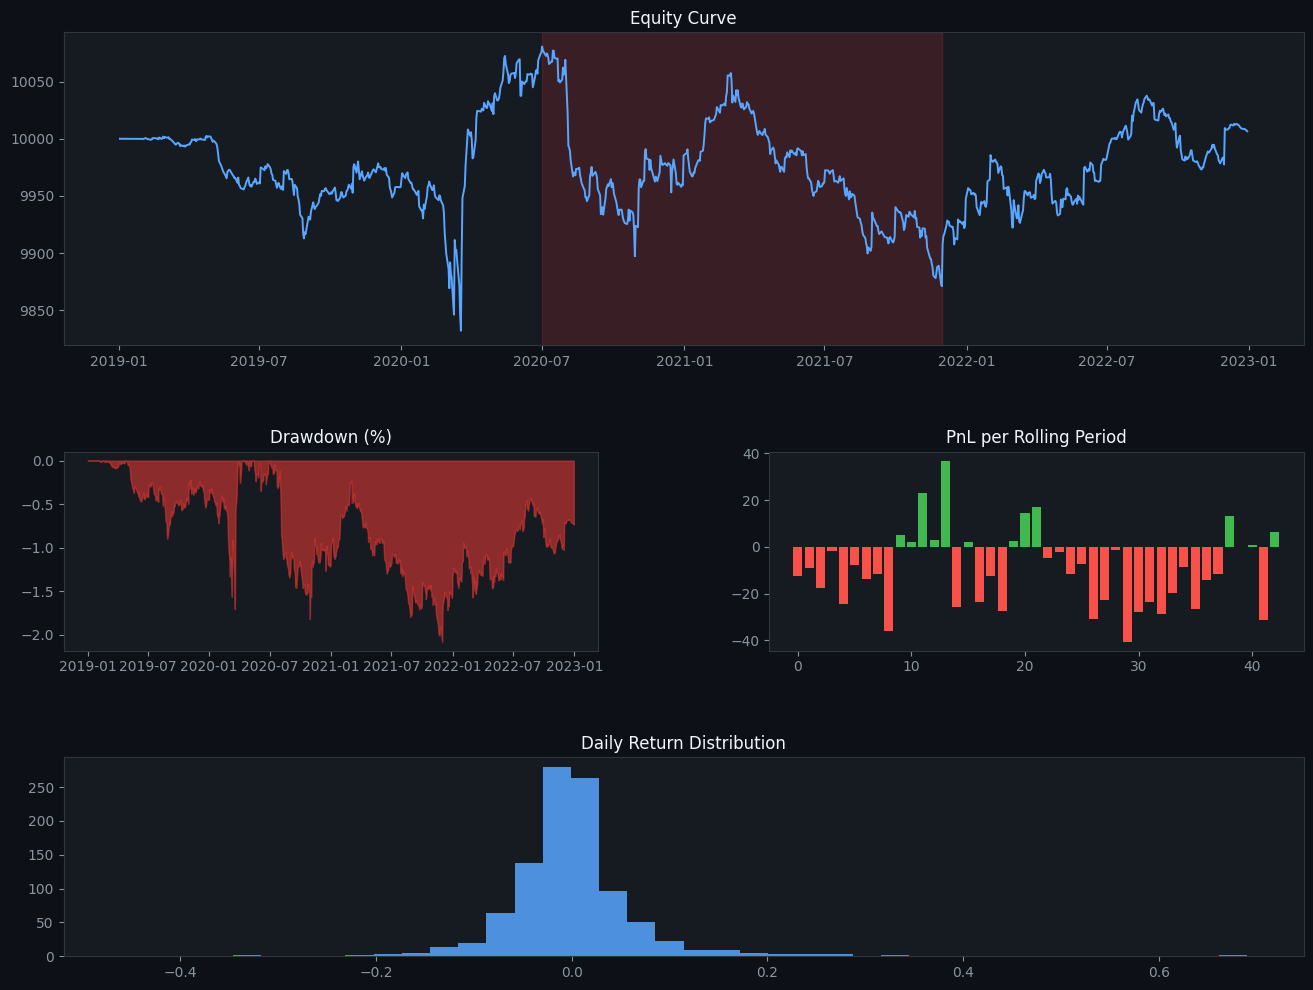

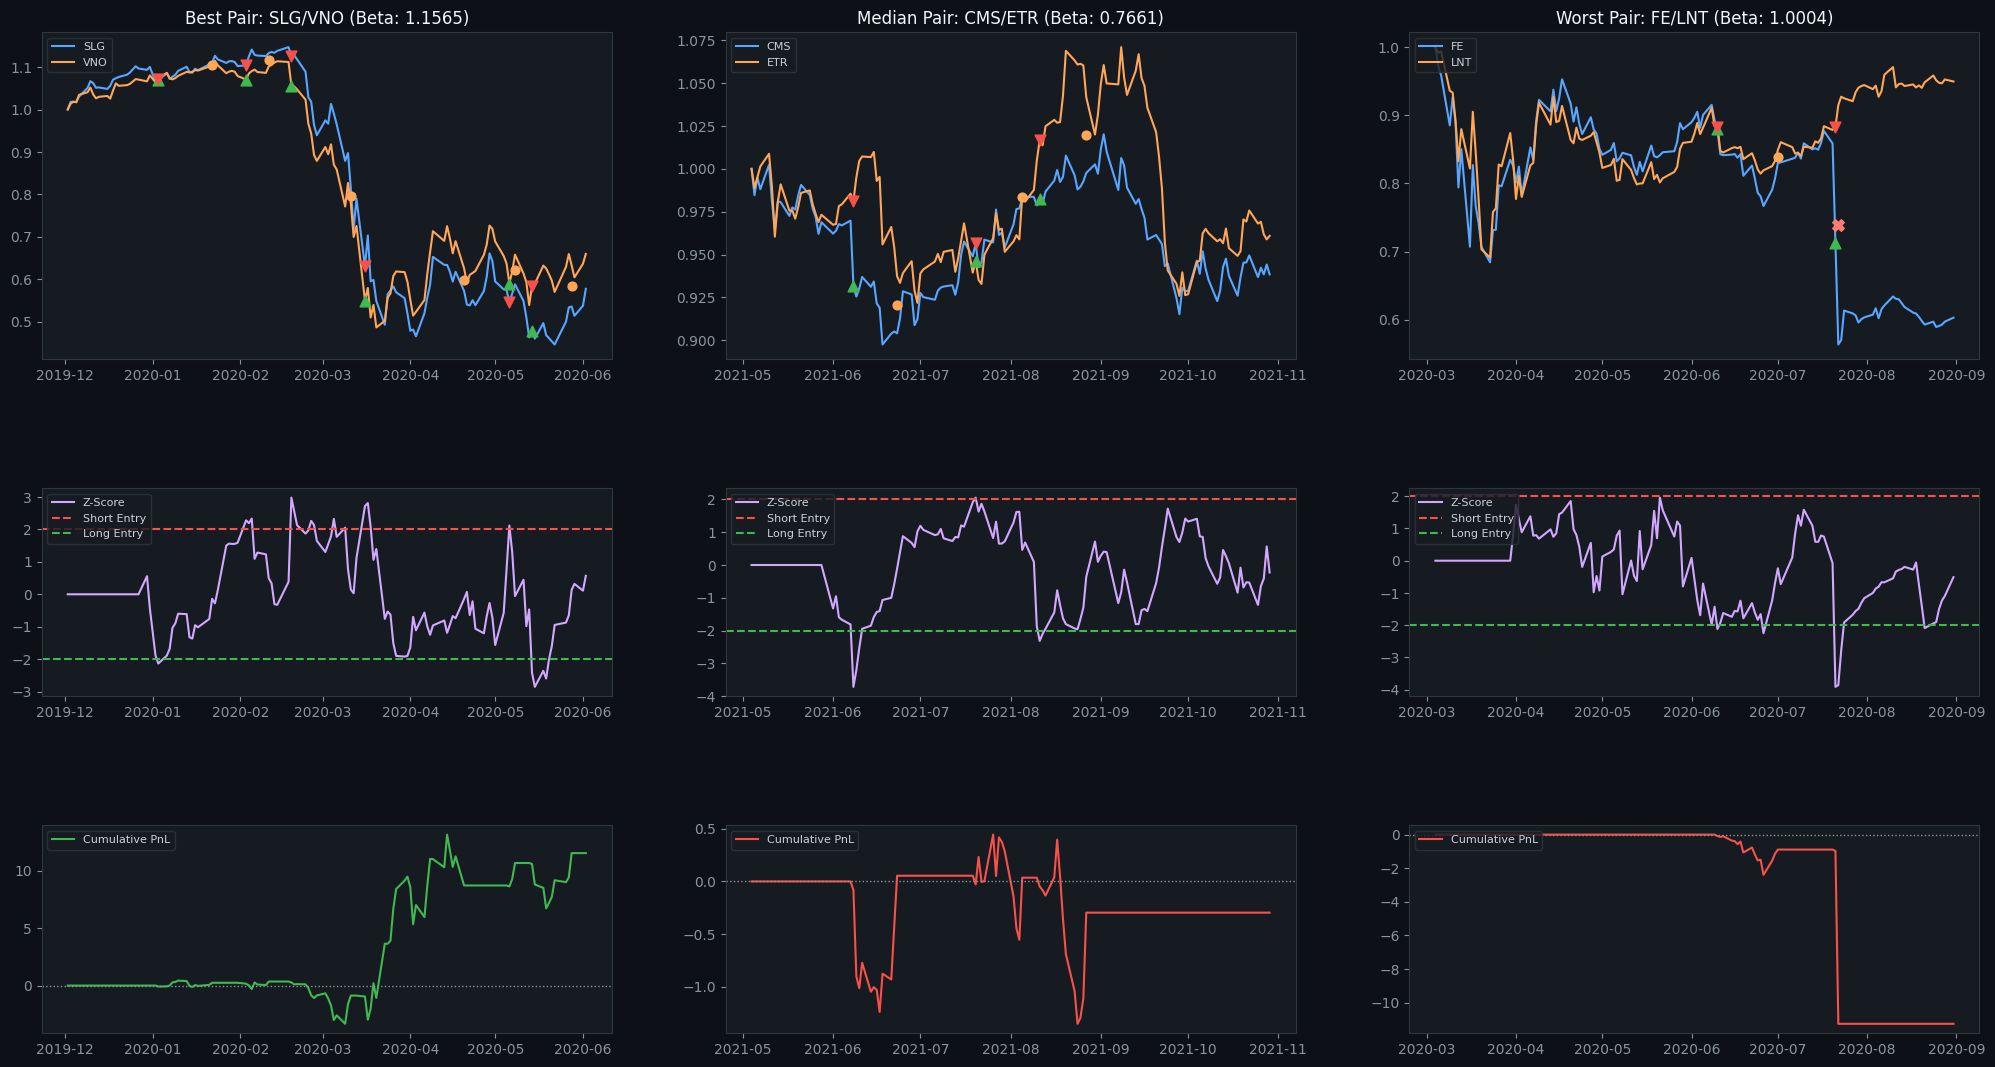

In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# 主程式（Main Block）
# ══════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    # 參數設定區
    DB_PATH, TABLE_NAME = r"../data/sp500.db", "daily_prices"
    BACKTEST_START, BACKTEST_END = "2019-01", "2022-12"
    
    # 策略視窗參數
    FORMATION_WINDOW, TRADING_WINDOW, ROLLING_STEP = 252, 126, 21
    TOP_N_PAIRS = 20
    
    # Z-Score 進出場門檻
    ENTRY_Z, EXIT_Z, ZSCORE_WINDOW = 2.0, 0.5, 20
    
    # 風控與資金參數
    STOP_LOSS_PCT, FEE_RATE, INITIAL_CAPITAL = 0.10, 0.001, 10000
    OUTPUT_DIR = r"../results"
    
    # 建立目錄
    FORMATION_OUTDIR, TRADING_OUTDIR = f"{OUTPUT_DIR}/Formation", f"{OUTPUT_DIR}/Trading"
    for d in [OUTPUT_DIR, FORMATION_OUTDIR, TRADING_OUTDIR]: Path(d).mkdir(parents=True, exist_ok=True)

    # 1. 載入並清理資料
    price_pivot = load_data_from_sqlite(DB_PATH, TABLE_NAME)
    price_pivot = price_pivot.loc[:, price_pivot.isnull().mean() < 0.20].ffill(limit=5)
    price_pivot.dropna(axis=1, thresh=int(len(price_pivot) * 0.9), inplace=True)

    bt_start_ts, bt_end_ts = _parse_date(BACKTEST_START) if BACKTEST_START else None, _parse_date(BACKTEST_END, is_end=True) if BACKTEST_END else None
    all_dates = price_pivot.index.tolist()

    data_slice_start = all_dates[max(0, [i for i, d in enumerate(all_dates) if d >= bt_start_ts][0] - FORMATION_WINDOW)] if bt_start_ts else price_pivot.index[0]
    data_slice_end = bt_end_ts if bt_end_ts else price_pivot.index[-1]
    price_pivot = price_pivot.loc[data_slice_start:data_slice_end]

    # 2. 回測前置準備
    all_dates, total_days = price_pivot.index.tolist(), len(price_pivot)
    local_first_trade_idx = max([i for i, d in enumerate(all_dates) if d >= bt_start_ts][0], FORMATION_WINDOW) if bt_start_ts else FORMATION_WINDOW

    perf = Performance(initial_capital=INITIAL_CAPITAL, output_dir=OUTPUT_DIR)
    perf.set_zscore_params(entry_z=ENTRY_Z, exit_z=EXIT_Z)

    max_concurrent = TRADING_WINDOW // ROLLING_STEP
    capital_per_pair = INITIAL_CAPITAL / max_concurrent / TOP_N_PAIRS
    capital_per_period = INITIAL_CAPITAL / max_concurrent

    roll_start_indices = list(range(local_first_trade_idx, total_days - TRADING_WINDOW + 1, ROLLING_STEP))

    # 3. 滾動回測主迴圈
    for roll_idx, trade_start_idx in enumerate(roll_start_indices):
        form_start_idx, form_end_idx = trade_start_idx - FORMATION_WINDOW, trade_start_idx
        trade_end_idx = min(trade_start_idx + TRADING_WINDOW, total_days)

        form_data, trade_data = price_pivot.iloc[form_start_idx:form_end_idx], price_pivot.iloc[trade_start_idx:trade_end_idx]
        
        # 移除有缺失值的標的
        valid_cols = (form_data.isnull().sum() + trade_data.isnull().sum()) == 0
        form_data, trade_data = form_data.loc[:, valid_cols], trade_data.loc[:, valid_cols]

        if form_data.shape[1] < 2 or trade_data.empty: continue

        period_start_str, trade_start_str, trade_end_str = str(all_dates[form_start_idx])[:10], str(all_dates[trade_start_idx])[:10], str(all_dates[trade_end_idx - 1])[:10]

        print(f"【第 {roll_idx+1:02d} 期】 {trade_start_str} ~ {trade_end_str}")

        # 執行 Formation
        formation = Formation(form_data, TOP_N_PAIRS, FORMATION_OUTDIR)
        selected_pairs = formation.run(period_start_str)
        if selected_pairs.empty: continue

        # 執行 Trading
        trading = Trading(trade_data, selected_pairs, capital_per_pair, FEE_RATE, STOP_LOSS_PCT, ENTRY_Z, EXIT_Z, ZSCORE_WINDOW, TRADING_OUTDIR)
        trade_log_df = trading.run(trade_start_str)

        # 寫入 Performance
        perf.add_period(trade_start_str, trade_end_str, trade_log_df, capital_per_period)

    # 4. 輸出最終報告
    perf.generate_report()
    print(f"\n✅ 回測完成！所有輸出檔案已儲存至: {OUTPUT_DIR}/")